✅ Data loaded: (150, 15)
     log_id           timestamp user_id            team  module_accessed  \
0  LOG-2000 2026-04-09 10:00:00  DEV-34  Infrastructure      Server Node   
1  LOG-2001 2026-04-09 10:00:20  DEV-66         Payment  Payment Gateway   
2  LOG-2002 2026-04-09 10:00:40  DEV-99        Frontend     Product Page   

                   action       issue_type error_code    error_message  \
0              Monitoring             None       None             None   
1  Transaction Processing             None       None             None   
2  Transaction Processing  Session Expired        403  Session expired   

  priority assigned_team       status  response_time_ms  cpu_usage_pct  \
0      Low          None         None               760             52   
1      Low          None         None               637             48   
2   Medium      Frontend  In Progress               501             78   

   memory_usage_mb  
0              912  
1             1167  
2            

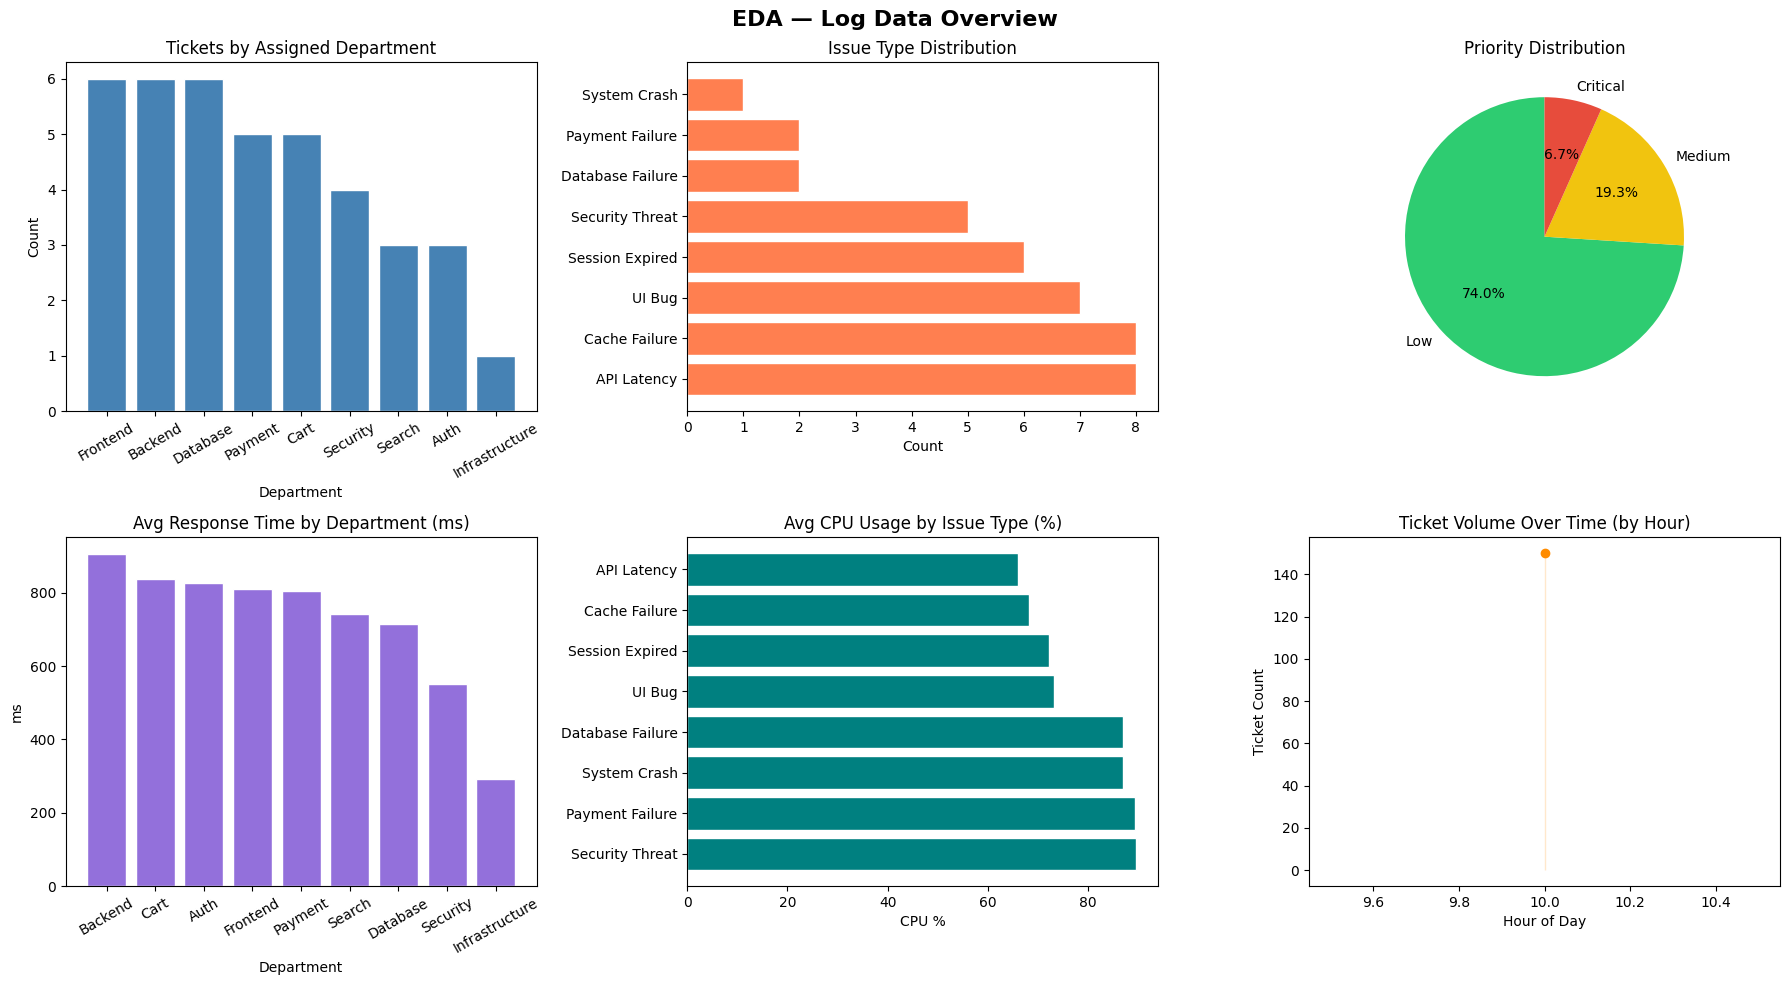

📊 EDA plot saved: eda_overview.png

KEYWORD EXTRACTION PER DEPARTMENT (TF-IDF)


ValueError: np.nan is an invalid document, expected byte or unicode string.

In [2]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────
# STEP 1 — LOAD & FLATTEN JSON DATA
# ─────────────────────────────────────────────

with open("realistic_logs_150.json", "r") as f:
    raw = json.load(f)

rows = []
for entry in raw:
    rows.append({
        "log_id":           entry["log_id"],
        "timestamp":        entry["timestamp"],
        "user_id":          entry["user_id"],
        "team":             entry["team"],
        "module_accessed":  entry["module_accessed"],
        "action":           entry["action"],
        "issue_type":       entry["issue_type"],
        "error_code":       entry["error_code"],
        "error_message":    entry["error_message"],
        "priority":         entry["ticket"]["priority"],
        "assigned_team":    entry["ticket"]["assigned_team"],
        "status":           entry["ticket"]["status"],
        "response_time_ms": entry["system_metrics"]["response_time_ms"],
        "cpu_usage_pct":    entry["system_metrics"]["cpu_usage_pct"],
        "memory_usage_mb":  entry["system_metrics"]["memory_usage_mb"],
    })

df = pd.DataFrame(rows)
df["timestamp"] = pd.to_datetime(df["timestamp"])
print("✅ Data loaded:", df.shape)
print(df.head(3))


# ─────────────────────────────────────────────
# STEP 2 — BASIC EDA
# ─────────────────────────────────────────────

print("\n" + "="*55)
print("BASIC EDA")
print("="*55)

print("\n── Data Types ──")
print(df.dtypes)

print("\n── Null Values ──")
print(df.isnull().sum())

print("\n── Assigned Team (Target) Distribution ──")
print(df["assigned_team"].value_counts())

print("\n── Priority Distribution ──")
print(df["priority"].value_counts())

print("\n── Issue Type Distribution ──")
print(df["issue_type"].value_counts())

print("\n── Ticket Status ──")
print(df["status"].value_counts())

print("\n── System Metrics Summary ──")
print(df[["response_time_ms", "cpu_usage_pct", "memory_usage_mb"]].describe())


# ─────────────────────────────────────────────
# STEP 3 — EDA VISUALIZATIONS
# ─────────────────────────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("EDA — Log Data Overview", fontsize=16, fontweight="bold")

# Plot 1: Assigned Team Distribution
team_counts = df["assigned_team"].value_counts()
axes[0, 0].bar(team_counts.index, team_counts.values, color="steelblue", edgecolor="white")
axes[0, 0].set_title("Tickets by Assigned Department")
axes[0, 0].set_xlabel("Department")
axes[0, 0].set_ylabel("Count")
axes[0, 0].tick_params(axis="x", rotation=30)

# Plot 2: Issue Type Distribution
issue_counts = df["issue_type"].value_counts()
axes[0, 1].barh(issue_counts.index, issue_counts.values, color="coral", edgecolor="white")
axes[0, 1].set_title("Issue Type Distribution")
axes[0, 1].set_xlabel("Count")

# Plot 3: Priority Distribution (Pie)
priority_counts = df["priority"].value_counts()
colors = {"Critical": "#e74c3c", "High": "#e67e22", "Medium": "#f1c40f", "Low": "#2ecc71"}
pie_colors = [colors.get(p, "grey") for p in priority_counts.index]
axes[0, 2].pie(priority_counts.values, labels=priority_counts.index,
               autopct="%1.1f%%", colors=pie_colors, startangle=90)
axes[0, 2].set_title("Priority Distribution")

# Plot 4: Avg Response Time by Team
avg_rt = df.groupby("assigned_team")["response_time_ms"].mean().sort_values(ascending=False)
axes[1, 0].bar(avg_rt.index, avg_rt.values, color="mediumpurple", edgecolor="white")
axes[1, 0].set_title("Avg Response Time by Department (ms)")
axes[1, 0].set_xlabel("Department")
axes[1, 0].set_ylabel("ms")
axes[1, 0].tick_params(axis="x", rotation=30)

# Plot 5: CPU Usage Distribution by Issue Type
issue_cpu = df.groupby("issue_type")["cpu_usage_pct"].mean().sort_values(ascending=False)
axes[1, 1].barh(issue_cpu.index, issue_cpu.values, color="teal", edgecolor="white")
axes[1, 1].set_title("Avg CPU Usage by Issue Type (%)")
axes[1, 1].set_xlabel("CPU %")

# Plot 6: Tickets over time (by hour)
df["hour"] = df["timestamp"].dt.hour
hourly = df.groupby("hour").size()
axes[1, 2].plot(hourly.index, hourly.values, marker="o", color="darkorange", linewidth=2)
axes[1, 2].fill_between(hourly.index, hourly.values, alpha=0.2, color="darkorange")
axes[1, 2].set_title("Ticket Volume Over Time (by Hour)")
axes[1, 2].set_xlabel("Hour of Day")
axes[1, 2].set_ylabel("Ticket Count")

plt.tight_layout()
plt.savefig("eda_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("📊 EDA plot saved: eda_overview.png")


# ─────────────────────────────────────────────
# STEP 4 — KEYWORD EXTRACTION (TF-IDF)
# ─────────────────────────────────────────────

print("\n" + "="*55)
print("KEYWORD EXTRACTION PER DEPARTMENT (TF-IDF)")
print("="*55)

# Combine all relevant text fields into one string per row
df["combined_text"] = (
    df["error_message"] + " " +
    df["module_accessed"] + " " +
    df["action"] + " " +
    df["issue_type"] + " " +
    df["error_code"]
)

# Fit TF-IDF per department
tfidf = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),   # unigrams + bigrams
    max_features=500
)

tfidf_matrix = tfidf.fit_transform(df["combined_text"])
feature_names = tfidf.get_feature_names_out()

# Extract top keywords per department
dept_keywords = {}
for dept in df["assigned_team"].unique():
    dept_mask = df["assigned_team"] == dept
    dept_tfidf = tfidf_matrix[dept_mask].toarray().mean(axis=0)
    top_indices = dept_tfidf.argsort()[::-1][:10]
    top_kw = [(feature_names[i], round(dept_tfidf[i], 4)) for i in top_indices]
    dept_keywords[dept] = top_kw
    print(f"\n🔑 [{dept}] Top Keywords:")
    for kw, score in top_kw:
        print(f"   {kw:<30} score: {score}")


# ─────────────────────────────────────────────
# STEP 5 — KEYWORD VISUALIZATION (per dept)
# ─────────────────────────────────────────────

n_depts = len(dept_keywords)
cols = 3
rows_v = (n_depts + cols - 1) // cols
fig, axes = plt.subplots(rows_v, cols, figsize=(18, rows_v * 4))
axes = axes.flatten()

for i, (dept, kws) in enumerate(dept_keywords.items()):
    words = [k[0] for k in kws]
    scores = [k[1] for k in kws]
    axes[i].barh(words[::-1], scores[::-1], color="steelblue", edgecolor="white")
    axes[i].set_title(f"🔑 {dept} — Top TF-IDF Keywords")
    axes[i].set_xlabel("TF-IDF Score")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Top Keywords per Department (TF-IDF)", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("keywords_per_dept.png", dpi=150, bbox_inches="tight")
plt.show()
print("📊 Keyword plot saved: keywords_per_dept.png")


# ─────────────────────────────────────────────
# STEP 6 — FEATURE ENGINEERING
# ─────────────────────────────────────────────

# Encode priority
priority_map = {"Low": 0, "Medium": 1, "High": 2, "Critical": 3}
df["priority_enc"] = df["priority"].map(priority_map)

# TF-IDF text features
X_text = tfidf_matrix.toarray()

# Numeric features
X_num = df[["response_time_ms", "cpu_usage_pct", "memory_usage_mb", "priority_enc"]].values

# Combine text + numeric
X = np.hstack([X_text, X_num])

# Target: assigned_team (department)
le = LabelEncoder()
y = le.fit_transform(df["assigned_team"])

print(f"\n✅ Feature matrix shape: {X.shape}")
print(f"✅ Classes: {list(le.classes_)}")


# ─────────────────────────────────────────────
# STEP 7 — TRAIN/TEST SPLIT & MODEL TRAINING
# ─────────────────────────────────────────────

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\n✅ Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

# Model 1 — Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("\n── Logistic Regression Report ──")
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))

# Model 2 — Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("\n── Random Forest Report ──")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))


# ─────────────────────────────────────────────
# STEP 8 — CONFUSION MATRIX
# ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, y_pred, title in zip(
    axes,
    [y_pred_lr, y_pred_rf],
    ["Logistic Regression", "Random Forest"]
):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
    disp.plot(ax=ax, colorbar=False, cmap="Blues", xticks_rotation=45)
    ax.set_title(f"Confusion Matrix — {title}")

plt.suptitle("Department Classification — Model Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("📊 Confusion matrix saved: confusion_matrix.png")


# ─────────────────────────────────────────────
# STEP 9 — FEATURE IMPORTANCE (Random Forest)
# ─────────────────────────────────────────────

all_feature_names = list(feature_names) + [
    "response_time_ms", "cpu_usage_pct", "memory_usage_mb", "priority_enc"
]
importances = rf.feature_importances_
top_idx = np.argsort(importances)[::-1][:20]

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(range(20), importances[top_idx], color="mediumseagreen", edgecolor="white")
ax.set_xticks(range(20))
ax.set_xticklabels([all_feature_names[i] for i in top_idx], rotation=45, ha="right")
ax.set_title("Top 20 Feature Importances — Random Forest")
ax.set_ylabel("Importance Score")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("📊 Feature importance saved: feature_importance.png")


# ─────────────────────────────────────────────
# STEP 10 — PREDICT ON NEW LOG ENTRY
# ─────────────────────────────────────────────

print("\n" + "="*55)
print("PREDICT DEPARTMENT FOR A NEW LOG ENTRY")
print("="*55)

new_log = {
    "error_message": "Redis cache not responding",
    "module_accessed": "Cache Layer",
    "action": "Cache Fetch",
    "issue_type": "Cache Miss",
    "error_code": "CACHE_FAILURE",
    "response_time_ms": 1800,
    "cpu_usage_pct": 72,
    "memory_usage_mb": 1100,
    "priority": "Medium"
}

new_text = (
    new_log["error_message"] + " " +
    new_log["module_accessed"] + " " +
    new_log["action"] + " " +
    new_log["issue_type"] + " " +
    new_log["error_code"]
)
new_text_vec = tfidf.transform([new_text]).toarray()
new_num = np.array([[
    new_log["response_time_ms"],
    new_log["cpu_usage_pct"],
    new_log["memory_usage_mb"],
    priority_map[new_log["priority"]]
]])
new_X = np.hstack([new_text_vec, new_num])

pred_dept = le.inverse_transform(rf.predict(new_X))[0]
proba = rf.predict_proba(new_X)[0]
dept_proba = sorted(zip(le.classes_, proba), key=lambda x: x[1], reverse=True)

print(f"\n📌 Input: {new_log['error_message']}")
print(f"✅ Predicted Department: {pred_dept}")
print("\n📊 Confidence per Department:")
for dept, prob in dept_proba:
    bar = "█" * int(prob * 30)
    print(f"   {dept:<12} {bar} {prob*100:.1f}%")

In [3]:
# ─────────────────────────────────────────────
# STEP 5 — OUTLIER DETECTION
# ─────────────────────────────────────────────

print("\n" + "="*55)
print("OUTLIER DETECTION (IQR + Z-Score)")
print("="*55)

outlier_flags = pd.DataFrame(index=df.index)

for col in numeric_cols:
    # IQR method
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_iqr = Q1 - 1.5 * IQR
    upper_iqr = Q3 + 1.5 * IQR
    iqr_flag = (df[col] < lower_iqr) | (df[col] > upper_iqr)

    # Z-Score method
    z_scores = np.abs(stats.zscore(df[col]))
    z_flag = z_scores > 3

    # Combined flag
    outlier_flags[col] = iqr_flag | z_flag
    n = outlier_flags[col].sum()
    print(f"  {col:<25} IQR bounds=[{lower_iqr:.0f}, {upper_iqr:.0f}] | "
          f"Z>3 count={z_flag.sum()} | Combined outliers={n}")

df["is_outlier"] = outlier_flags.any(axis=1)
print(f"\n  ✅ Total outlier rows: {df['is_outlier'].sum()} / {len(df)}")
print("\n  Sample outlier rows:")
print(df[df["is_outlier"]][["log_id", "assigned_team", "issue_type",
                              "response_time_ms", "cpu_usage_pct",
                              "memory_usage_mb"]].head(10).to_string(index=False))

# ── Plot A: Boxplots (showing outliers as red dots) ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Boxplots — Outliers Visible as Red Dots", fontsize=14, fontweight="bold")
for ax, col in zip(axes, numeric_cols):
    ax.boxplot(df[col], vert=True, patch_artist=True,
               boxprops=dict(facecolor="steelblue", color="navy"),
               medianprops=dict(color="red", linewidth=2),
               flierprops=dict(marker="o", color="crimson",
                               markerfacecolor="crimson", markersize=6))
    ax.set_title(col)
    ax.set_ylabel("Value")
plt.tight_layout()
plt.savefig("outliers_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()
print("📊 Saved: outliers_boxplot.png")

# ── Plot B: Grouped Boxplots by Department ──
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Outliers by Department — Grouped Boxplots", fontsize=14, fontweight="bold")
dept_order = sorted(df["assigned_team"].unique())
for ax, col in zip(axes, numeric_cols):
    data_grouped = [df[df["assigned_team"] == d][col].values for d in dept_order]
    bp = ax.boxplot(data_grouped, labels=dept_order, patch_artist=True,
                    flierprops=dict(marker="o", color="crimson",
                                    markerfacecolor="crimson", markersize=4))
    clrs = plt.cm.tab10(np.linspace(0, 1, len(dept_order)))
    for patch, c in zip(bp["boxes"], clrs):
        patch.set_facecolor(c)
    ax.set_title(col)
    ax.set_xlabel("Department")
    ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.savefig("outliers_by_dept.png", dpi=150, bbox_inches="tight")
plt.show()
print("📊 Saved: outliers_by_dept.png")

# ── Plot C: Scatter — Normal vs Outlier ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Outlier Scatter — Red=Outlier, Blue=Normal", fontsize=14, fontweight="bold")
for ax, (xc, yc) in zip(axes, [
    ("response_time_ms", "cpu_usage_pct"),
    ("cpu_usage_pct",    "memory_usage_mb")
]):
    for flag, color, label, sz in [
        (False, "steelblue", "Normal", 25),
        (True,  "crimson",   "Outlier", 70)
    ]:
        m = df["is_outlier"] == flag
        ax.scatter(df[m][xc], df[m][yc], c=color, label=label,
                   alpha=0.75, s=sz, edgecolors="white", linewidth=0.4)
    ax.set_xlabel(xc); ax.set_ylabel(yc)
    ax.set_title(f"{xc} vs {yc}")
    ax.legend()
plt.tight_layout()
plt.savefig("outliers_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print("📊 Saved: outliers_scatter.png")

# ── Plot D: Outlier count per Department ──
outlier_by_dept = df[df["is_outlier"]]["assigned_team"].value_counts()
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(outlier_by_dept.index, outlier_by_dept.values, color="crimson", edgecolor="white")
ax.set_title("Outlier Ticket Count per Department", fontsize=13, fontweight="bold")
ax.set_xlabel("Department"); ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig("outliers_per_dept.png", dpi=150, bbox_inches="tight")
plt.show()
print("📊 Saved: outliers_per_dept.png")


OUTLIER DETECTION (IQR + Z-Score)


NameError: name 'numeric_cols' is not defined

Data loaded: (90, 15)
     log_id           timestamp user_id      team module_accessed  \
0  LOG-2001 2026-04-09 10:00:01  DEV-11      Auth   Login Service   
1  LOG-2002 2026-04-09 10:05:10  DEV-22   Backend   Order Service   
2  LOG-2003 2026-04-09 10:07:45  DEV-33  Frontend    Product Page   

               action              issue_type        error_code  \
0  User Login Attempt  Authentication Failure  401_UNAUTHORIZED   
1       Placing Order        Database Failure      500_DB_ERROR   
2           Page Load             API Latency       504_TIMEOUT   

                      error_message  priority assigned_team status  \
0  Invalid token or session expired      High          Auth   Open   
1       Connection timeout to MySQL  Critical      Database   Open   
2      Product API response delayed    Medium       Backend   Open   

   response_time_ms  cpu_usage_pct  memory_usage_mb  
0              1500             70              850  
1              4000             85         

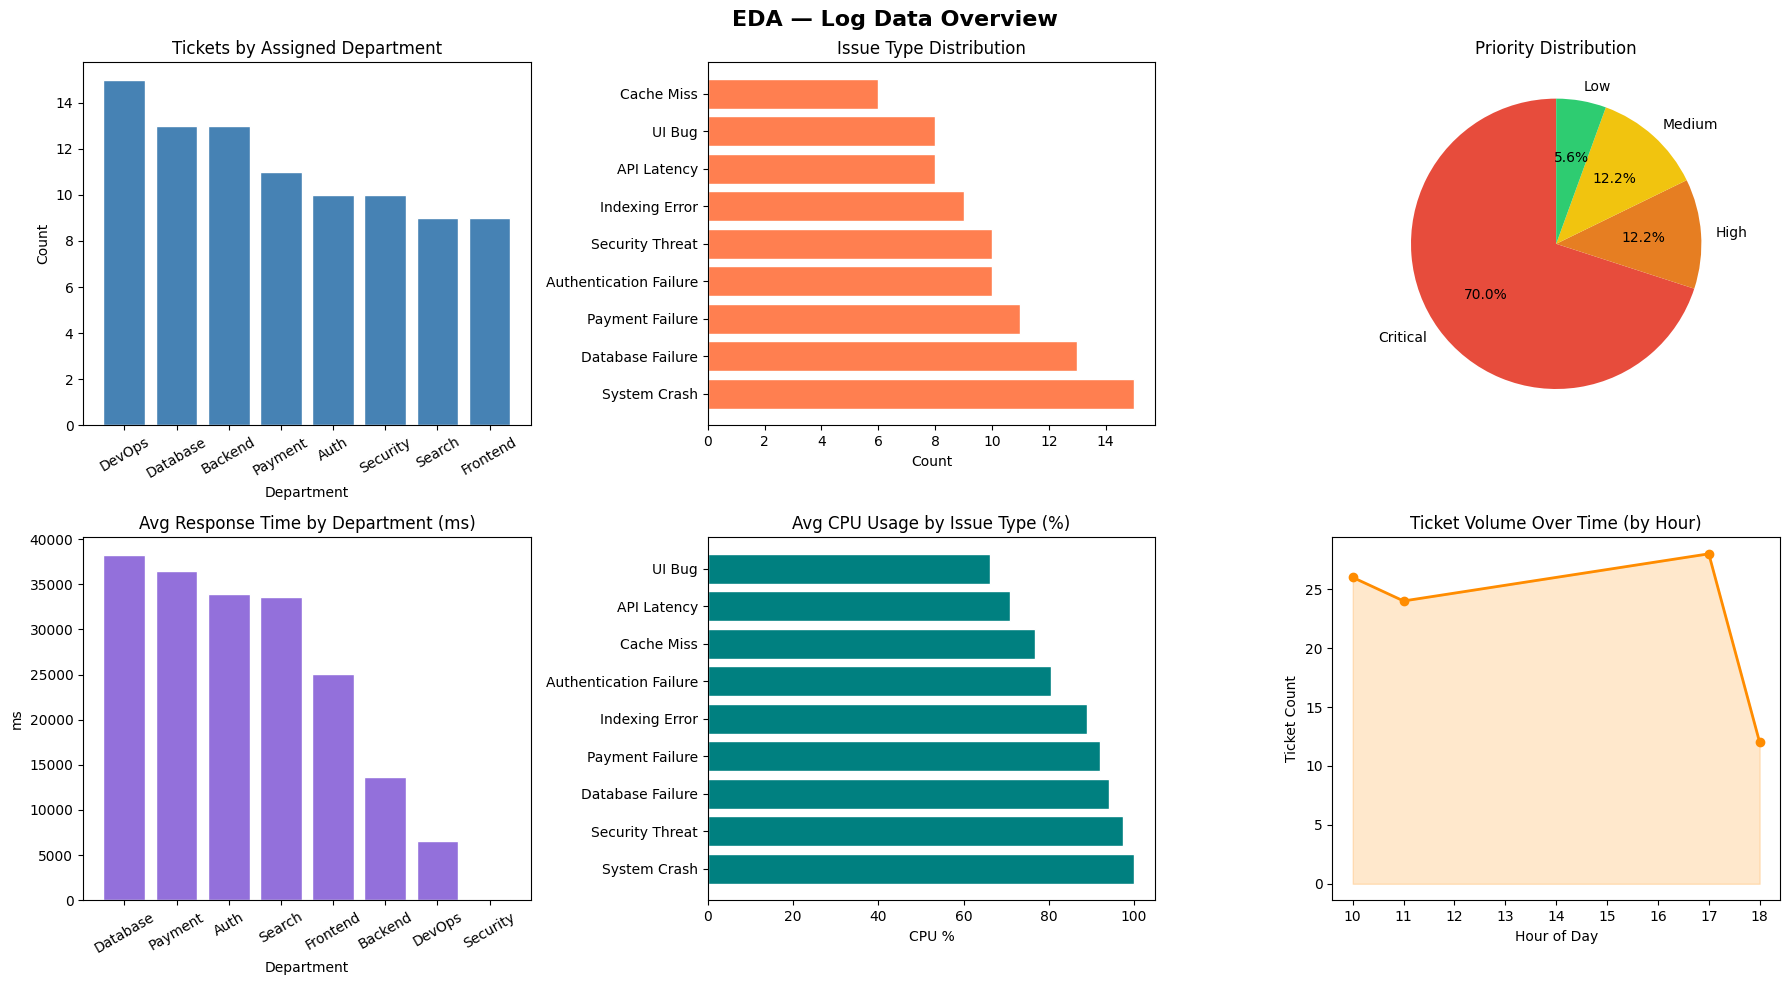

Saved: eda_overview.png

DISTRIBUTION ANALYSIS — BEFORE TREATMENT
  response_time_ms          skewness=1.100  kurtosis=-0.527
  cpu_usage_pct             skewness=-1.124  kurtosis=0.062
  memory_usage_mb           skewness=0.584  kurtosis=-1.659


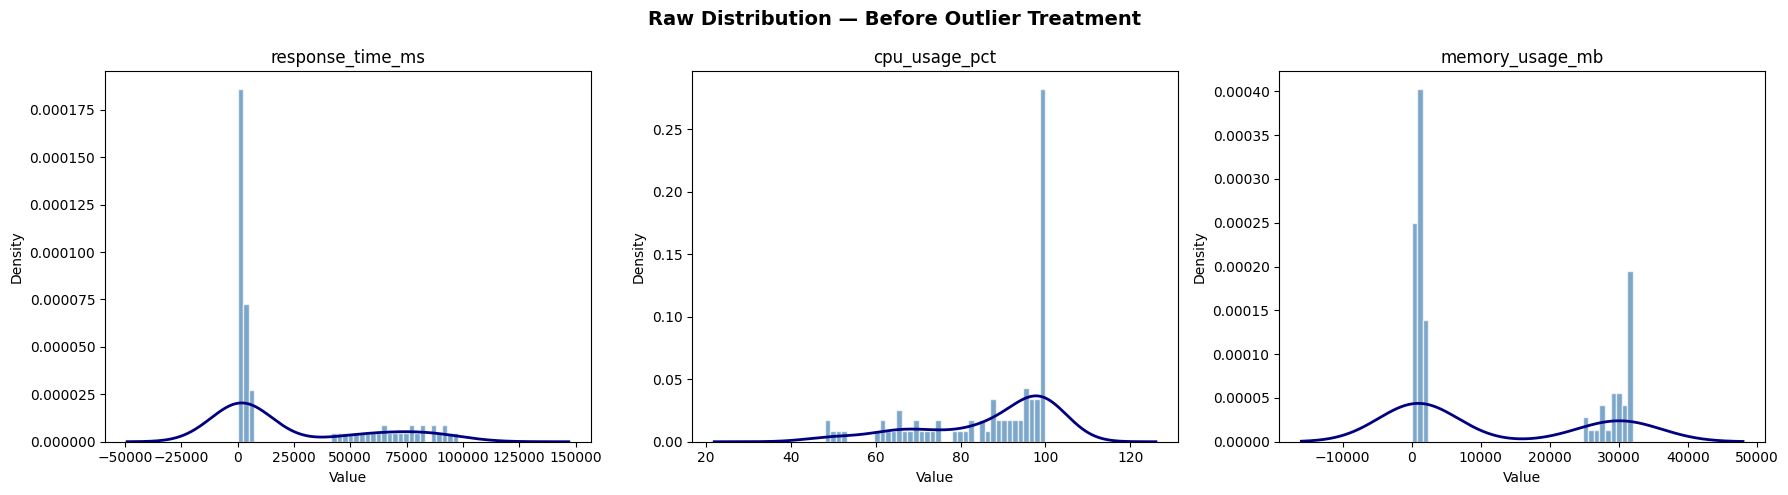

Saved: dist_before.png

OUTLIER DETECTION (IQR + Z-Score)
  response_time_ms          IQR bounds=[-77094, 129056] | Z>3 count=0 | Combined outliers=0
  cpu_usage_pct             IQR bounds=[48, 131] | Z>3 count=0 | Combined outliers=1
  memory_usage_mb           IQR bounds=[-41619, 71611] | Z>3 count=0 | Combined outliers=0

  Total outlier rows: 1 / 90

  Sample outlier rows:
  log_id assigned_team issue_type  response_time_ms  cpu_usage_pct  memory_usage_mb
LOG-2018      Frontend     UI Bug               850             48              680


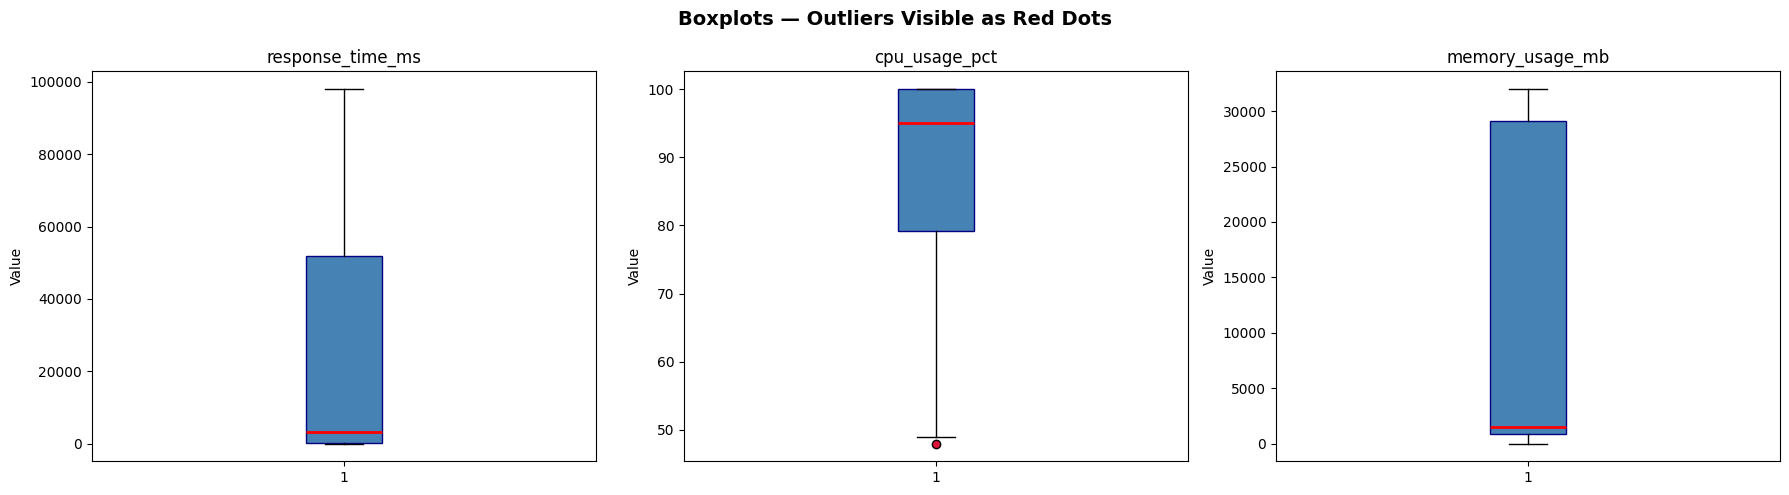

Saved: outliers_boxplot.png


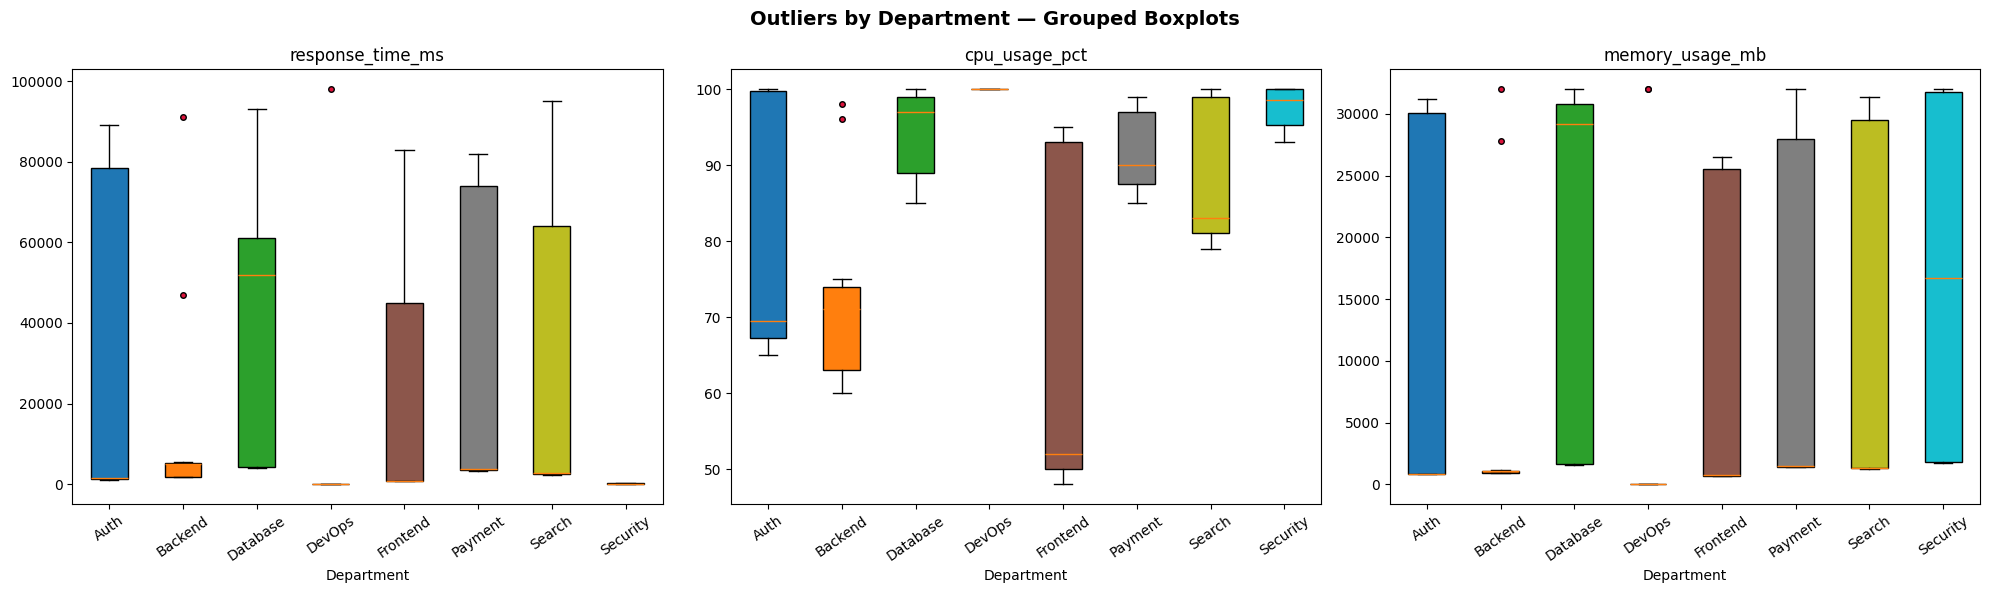

Saved: outliers_by_dept.png


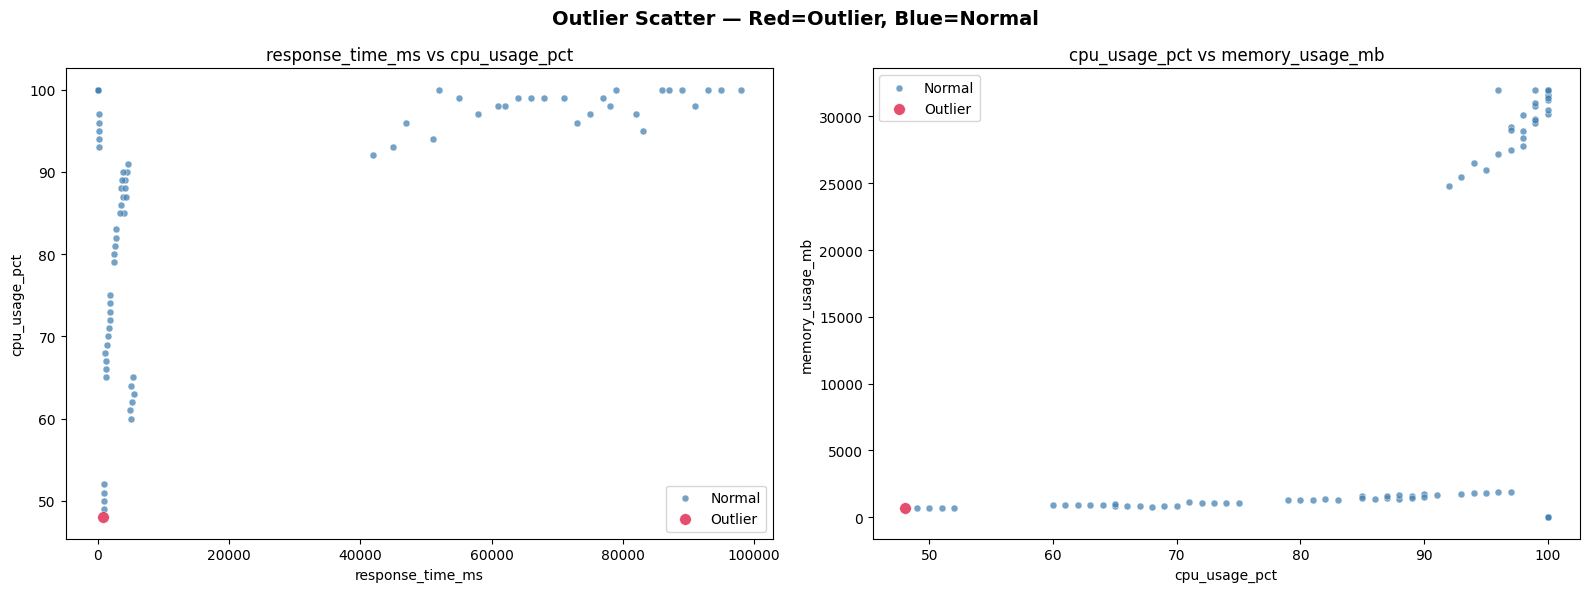

Saved: outliers_scatter.png

  Outlier breakdown by department:
assigned_team
Frontend    1
Name: count, dtype: int64


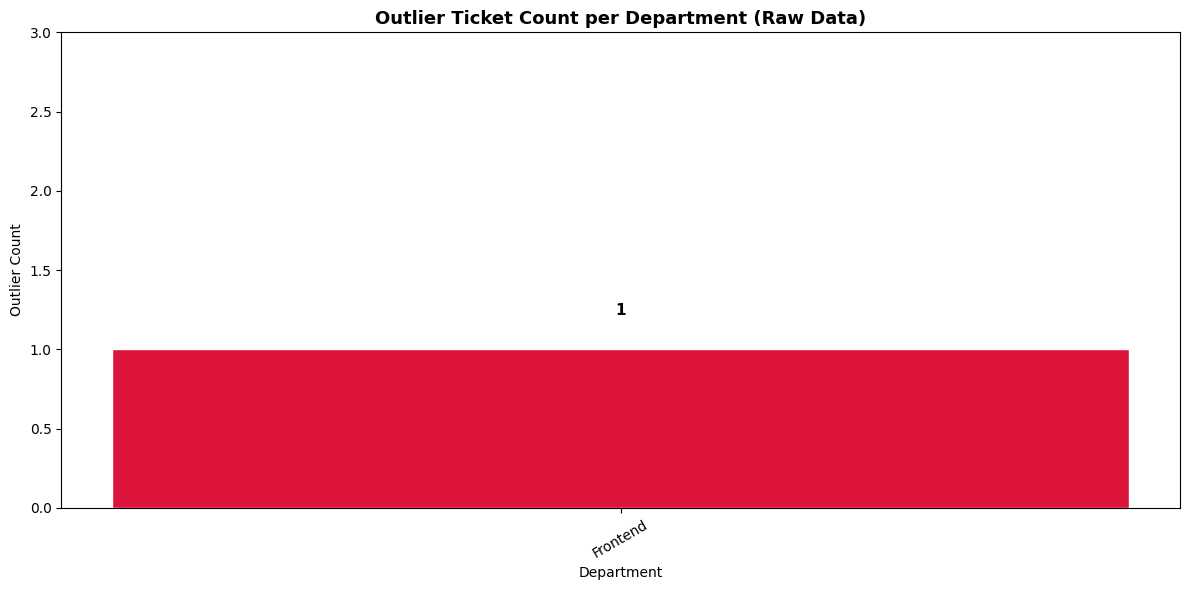

Saved: outliers_per_dept.png

OUTLIER TREATMENT — WINSORIZATION (Capping at 1st/99th percentile)
  response_time_ms          capped to [0, 95330] | mean: 22688.1 -> 22658.4
  cpu_usage_pct             capped to [49, 100] | mean: 87.5 -> 87.5
  memory_usage_mb           capped to [0, 32000] | mean: 11567.9 -> 11567.9

  Skewness after Winsorization:
  response_time_ms          skewness=1.095
  cpu_usage_pct             skewness=-1.119
  memory_usage_mb           skewness=0.584


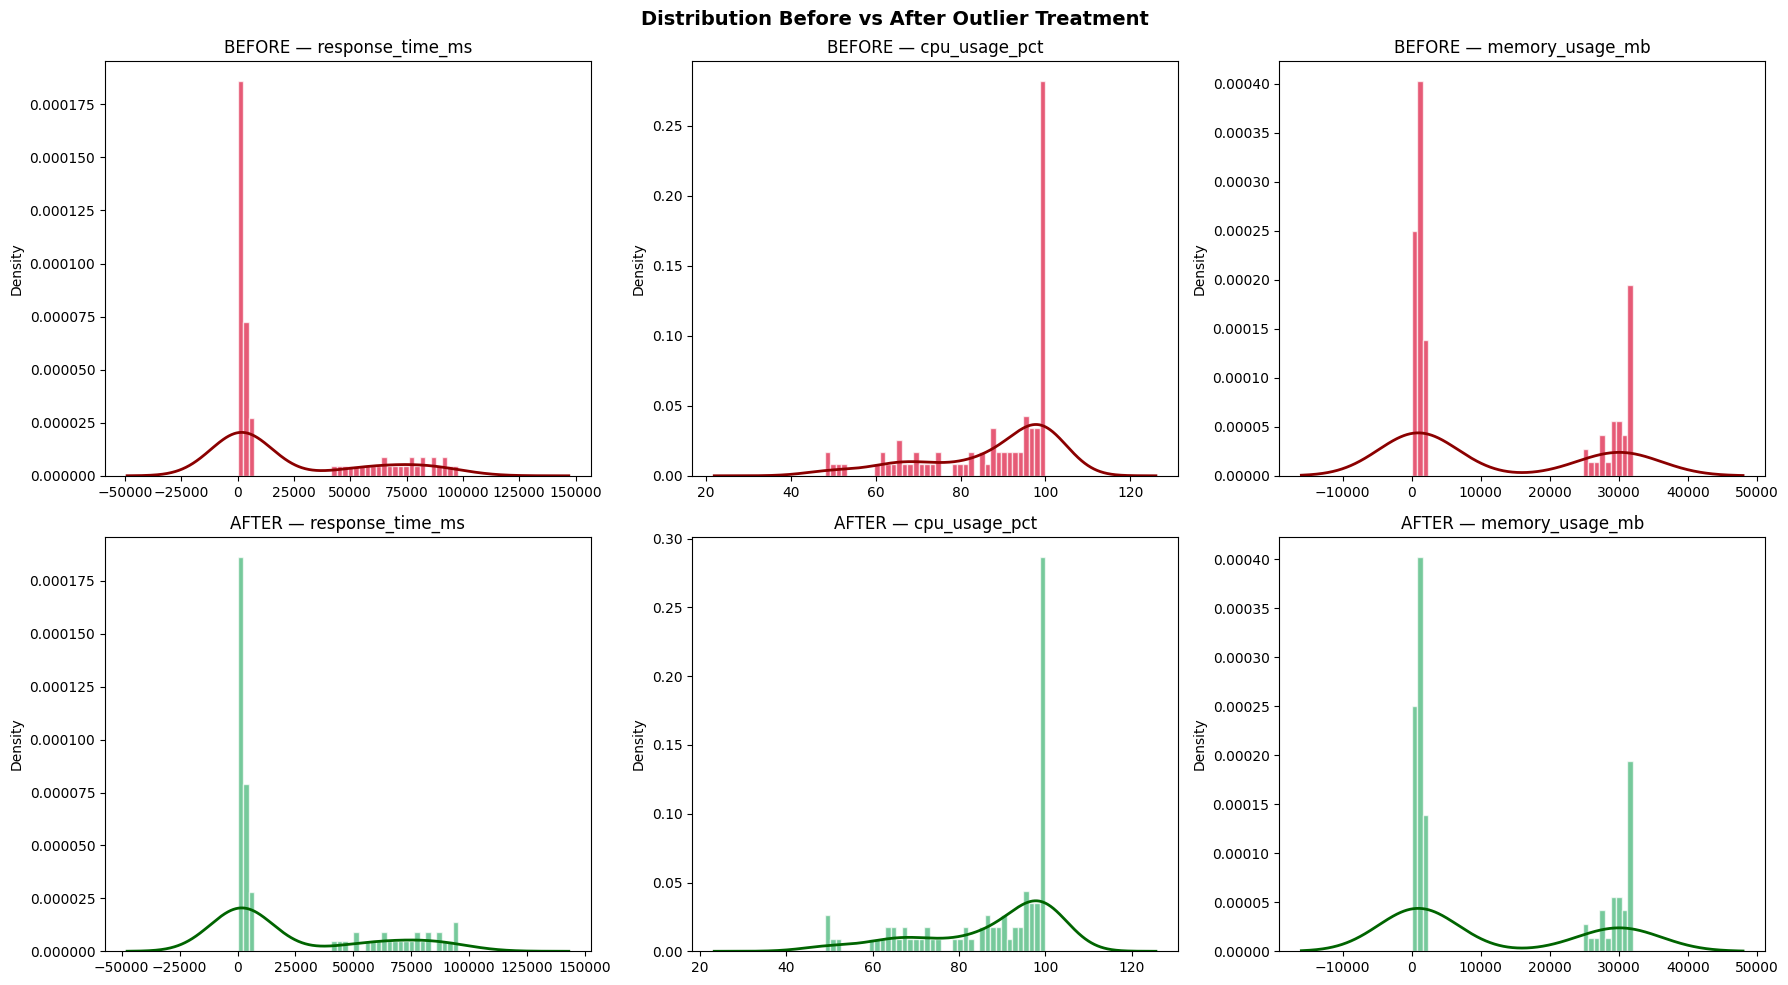

Saved: dist_before_after.png


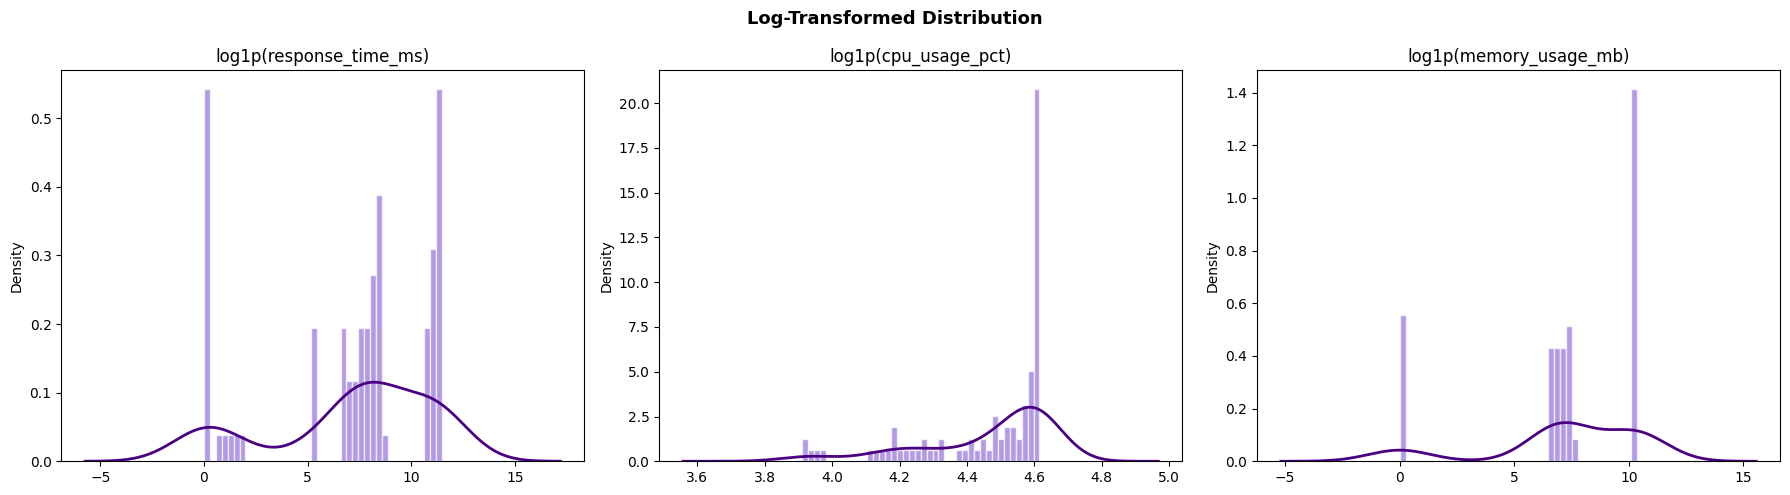

Saved: dist_log_transform.png

Outlier treatment complete. Using cleaned data for ML pipeline.

KEYWORD EXTRACTION PER DEPARTMENT (TF-IDF)

[Auth] Top Keywords:
   login                          score: 0.2585
   authentication                 score: 0.1836
   authentication failure         score: 0.1836
   401_unauthorized               score: 0.1836
   failure 401_unauthorized       score: 0.1836
   service                        score: 0.1207
   failure                        score: 0.1121
   login attempt                  score: 0.1117
   service user                   score: 0.1117
   login service                  score: 0.1117

[Database] Top Keywords:
   failure 500_db_error           score: 0.1557
   database failure               score: 0.1557
   500_db_error                   score: 0.1557
   database                       score: 0.1484
   service                        score: 0.1151
   failure                        score: 0.103
   order                          score: 0.100

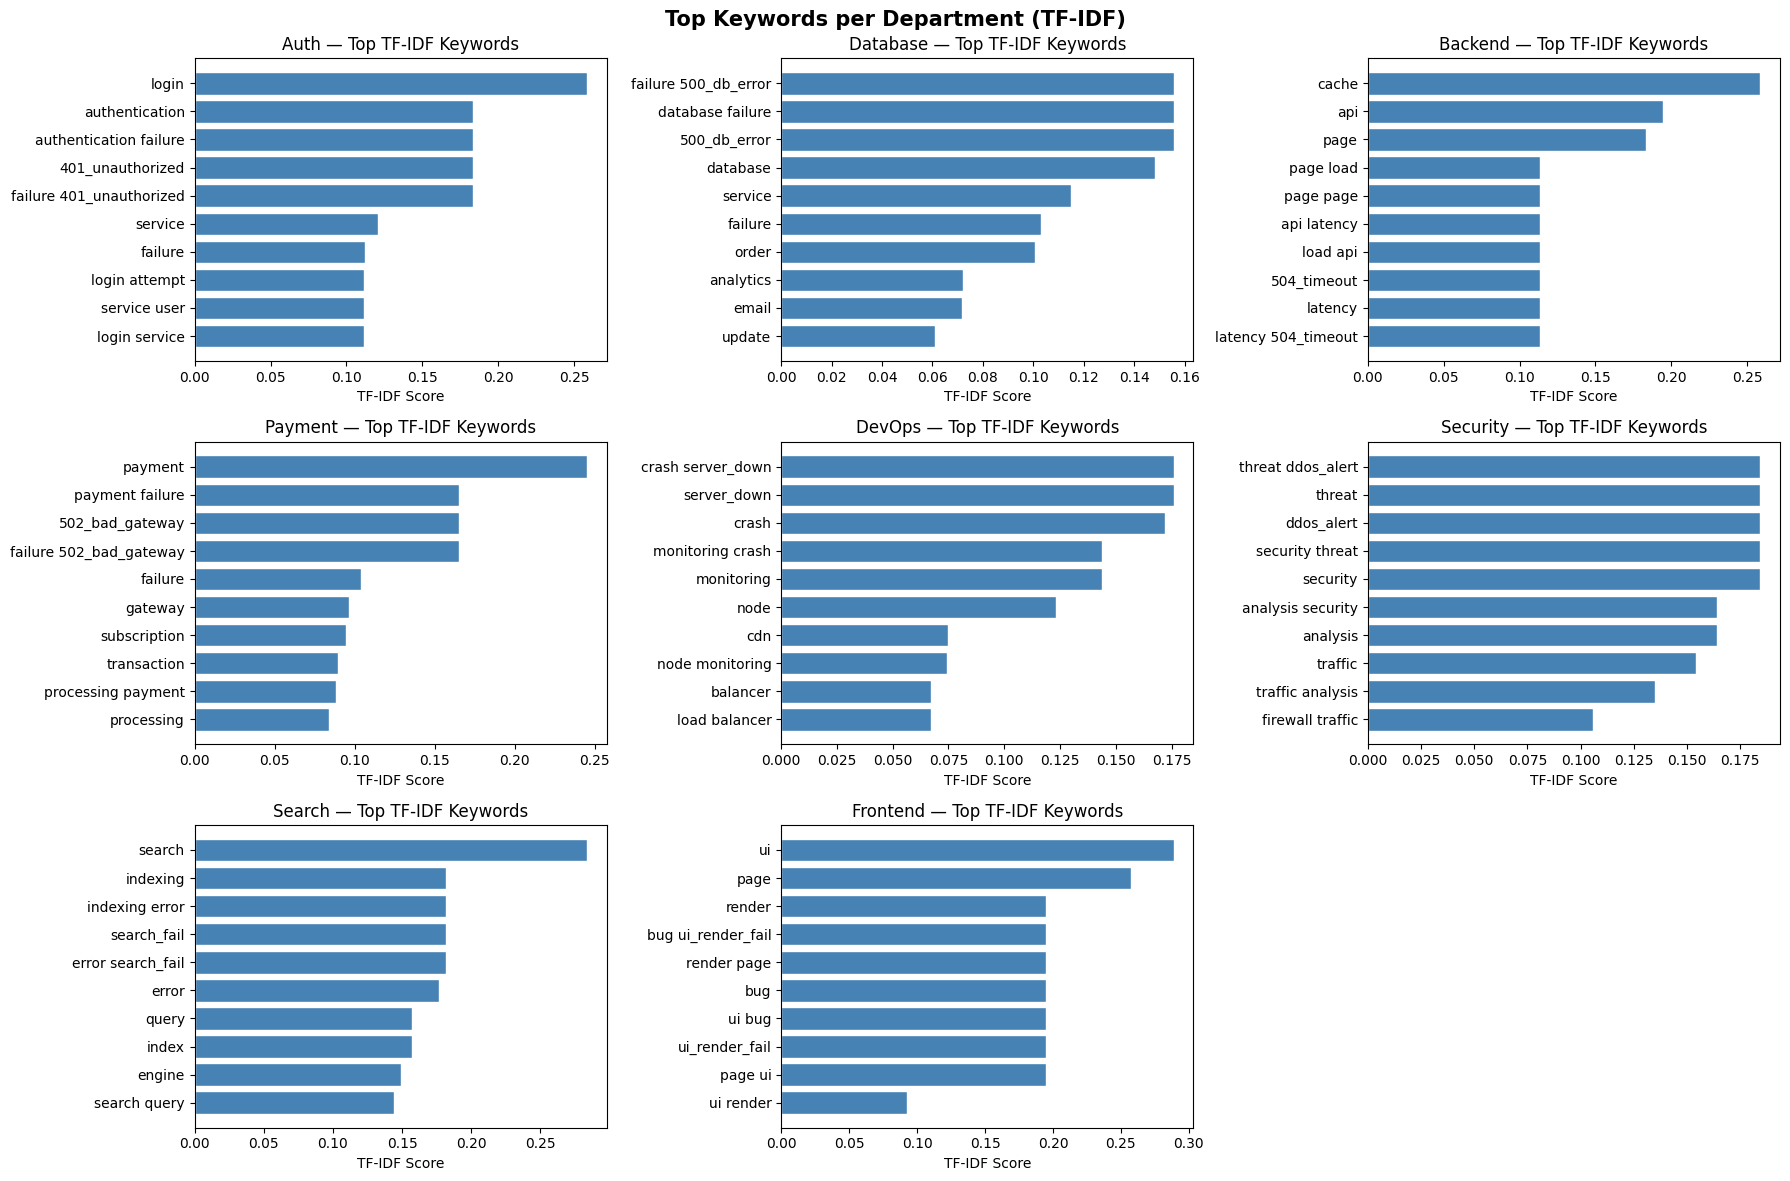

Saved: keywords_per_dept.png

Feature matrix shape: (90, 505)
Classes: ['Auth', 'Backend', 'Database', 'DevOps', 'Frontend', 'Payment', 'Search', 'Security']

Train size: 72, Test size: 18

-- Logistic Regression Report --
              precision    recall  f1-score   support

        Auth       0.00      0.00      0.00         2
     Backend       0.00      0.00      0.00         3
    Database       1.00      0.50      0.67         2
      DevOps       0.15      0.67      0.25         3
    Frontend       0.00      0.00      0.00         2
     Payment       0.00      0.00      0.00         2
      Search       0.00      0.00      0.00         2
    Security       0.67      1.00      0.80         2

    accuracy                           0.28        18
   macro avg       0.23      0.27      0.21        18
weighted avg       0.21      0.28      0.20        18


-- Random Forest Report --
              precision    recall  f1-score   support

        Auth       1.00      1.00      1.00

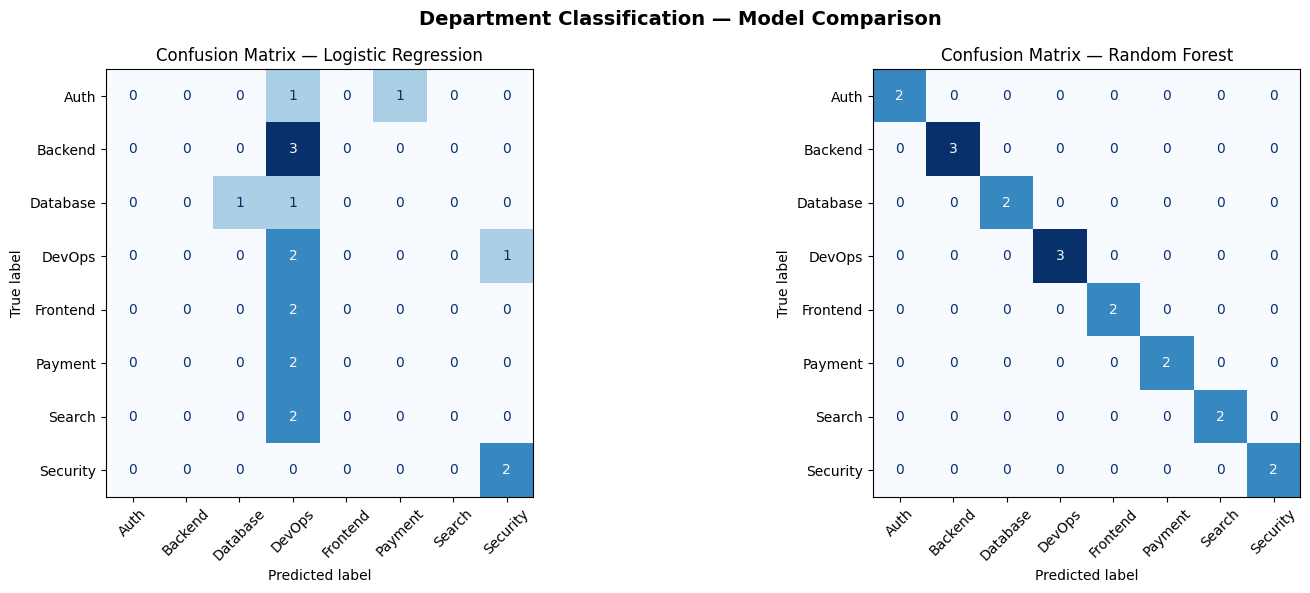

Saved: confusion_matrix.png


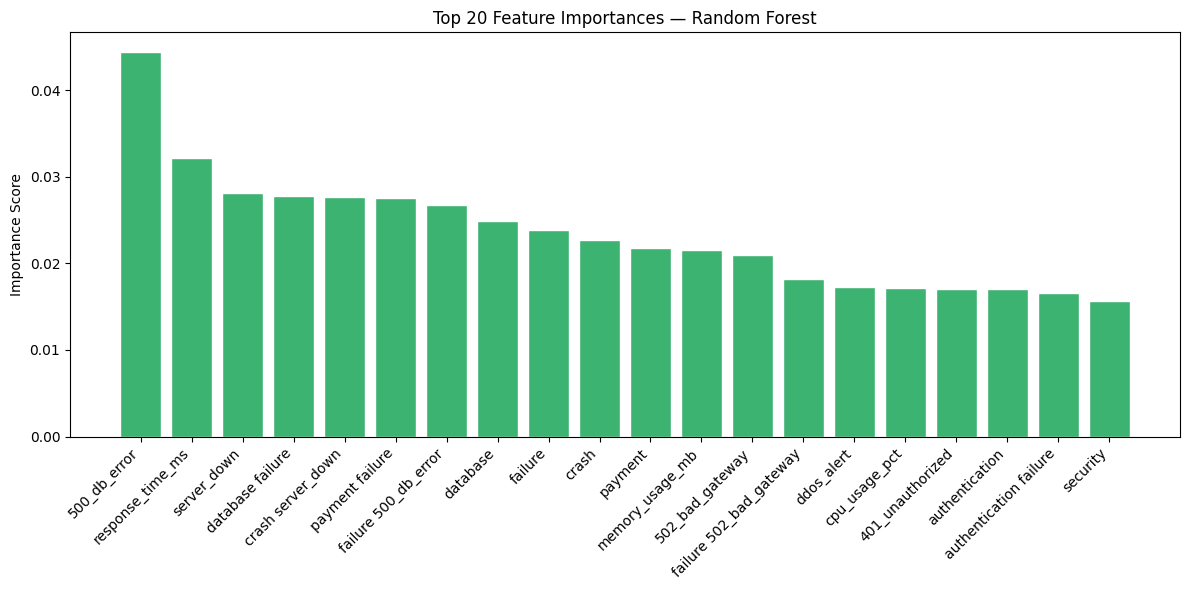

Saved: feature_importance.png

PREDICT DEPARTMENT FOR A NEW LOG ENTRY

Input: Redis cache not responding
Predicted Department: Backend

Confidence per Department:
   Backend      |||||||||||||||||||||||||||| 95.0%
   Auth          2.0%
   DevOps        1.0%
   Frontend      0.5%
   Payment       0.5%
   Search        0.5%
   Security      0.5%
   Database      0.0%


In [6]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from scipy import stats
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings("ignore")


# ─────────────────────────────────────────────
# STEP 1 — LOAD & FLATTEN JSON DATA
# ─────────────────────────────────────────────

with open("log_data.json", "r") as f:
    raw = json.load(f)

rows = []
for entry in raw:
    rows.append({
        "log_id":           entry["log_id"],
        "timestamp":        entry["timestamp"],
        "user_id":          entry["user_id"],
        "team":             entry["team"],
        "module_accessed":  entry["module_accessed"],
        "action":           entry["action"],
        "issue_type":       entry["issue_type"],
        "error_code":       entry["error_code"],
        "error_message":    entry["error_message"],
        "priority":         entry["ticket"]["priority"],
        "assigned_team":    entry["ticket"]["assigned_team"],
        "status":           entry["ticket"]["status"],
        "response_time_ms": entry["system_metrics"]["response_time_ms"],
        "cpu_usage_pct":    entry["system_metrics"]["cpu_usage_pct"],
        "memory_usage_mb":  entry["system_metrics"]["memory_usage_mb"],
    })

df = pd.DataFrame(rows)
df["timestamp"] = pd.to_datetime(df["timestamp"])
print("Data loaded:", df.shape)
print(df.head(3))


# ─────────────────────────────────────────────
# STEP 2 — BASIC EDA
# ─────────────────────────────────────────────

print("\n" + "="*55)
print("BASIC EDA")
print("="*55)

print("\n-- Data Types --")
print(df.dtypes)

print("\n-- Null Values --")
print(df.isnull().sum())

print("\n-- Assigned Team (Target) Distribution --")
print(df["assigned_team"].value_counts())

print("\n-- Priority Distribution --")
print(df["priority"].value_counts())

print("\n-- Issue Type Distribution --")
print(df["issue_type"].value_counts())

print("\n-- Ticket Status --")
print(df["status"].value_counts())

print("\n-- System Metrics Summary --")
print(df[["response_time_ms", "cpu_usage_pct", "memory_usage_mb"]].describe())


# ─────────────────────────────────────────────
# STEP 3 — EDA VISUALIZATIONS
# ─────────────────────────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("EDA — Log Data Overview", fontsize=16, fontweight="bold")

team_counts = df["assigned_team"].value_counts()
axes[0, 0].bar(team_counts.index, team_counts.values, color="steelblue", edgecolor="white")
axes[0, 0].set_title("Tickets by Assigned Department")
axes[0, 0].set_xlabel("Department")
axes[0, 0].set_ylabel("Count")
axes[0, 0].tick_params(axis="x", rotation=30)

issue_counts = df["issue_type"].value_counts()
axes[0, 1].barh(issue_counts.index, issue_counts.values, color="coral", edgecolor="white")
axes[0, 1].set_title("Issue Type Distribution")
axes[0, 1].set_xlabel("Count")

priority_counts = df["priority"].value_counts()
colors = {"Critical": "#e74c3c", "High": "#e67e22", "Medium": "#f1c40f", "Low": "#2ecc71"}
pie_colors = [colors.get(p, "grey") for p in priority_counts.index]
axes[0, 2].pie(priority_counts.values, labels=priority_counts.index,
               autopct="%1.1f%%", colors=pie_colors, startangle=90)
axes[0, 2].set_title("Priority Distribution")

avg_rt = df.groupby("assigned_team")["response_time_ms"].mean().sort_values(ascending=False)
axes[1, 0].bar(avg_rt.index, avg_rt.values, color="mediumpurple", edgecolor="white")
axes[1, 0].set_title("Avg Response Time by Department (ms)")
axes[1, 0].set_xlabel("Department")
axes[1, 0].set_ylabel("ms")
axes[1, 0].tick_params(axis="x", rotation=30)

issue_cpu = df.groupby("issue_type")["cpu_usage_pct"].mean().sort_values(ascending=False)
axes[1, 1].barh(issue_cpu.index, issue_cpu.values, color="teal", edgecolor="white")
axes[1, 1].set_title("Avg CPU Usage by Issue Type (%)")
axes[1, 1].set_xlabel("CPU %")

df["hour"] = df["timestamp"].dt.hour
hourly = df.groupby("hour").size()
axes[1, 2].plot(hourly.index, hourly.values, marker="o", color="darkorange", linewidth=2)
axes[1, 2].fill_between(hourly.index, hourly.values, alpha=0.2, color="darkorange")
axes[1, 2].set_title("Ticket Volume Over Time (by Hour)")
axes[1, 2].set_xlabel("Hour of Day")
axes[1, 2].set_ylabel("Ticket Count")

plt.tight_layout()
plt.savefig("eda_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: eda_overview.png")


# ─────────────────────────────────────────────
# STEP 4 — DISTRIBUTION CHECK (Before Fix)
# ─────────────────────────────────────────────

print("\n" + "="*55)
print("DISTRIBUTION ANALYSIS — BEFORE TREATMENT")
print("="*55)

numeric_cols = ["response_time_ms", "cpu_usage_pct", "memory_usage_mb"]

for col in numeric_cols:
    sk = df[col].skew()
    ku = df[col].kurtosis()
    print(f"  {col:<25} skewness={sk:.3f}  kurtosis={ku:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Raw Distribution — Before Outlier Treatment", fontsize=14, fontweight="bold")
for ax, col in zip(axes, numeric_cols):
    ax.hist(df[col], bins=40, color="steelblue", edgecolor="white", density=True, alpha=0.7)
    df[col].plot.kde(ax=ax, color="navy", linewidth=2)
    ax.set_title(col)
    ax.set_xlabel("Value")
    ax.set_ylabel("Density")
plt.tight_layout()
plt.savefig("dist_before.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: dist_before.png")


# ─────────────────────────────────────────────
# STEP 5 — OUTLIER DETECTION
# ─────────────────────────────────────────────

print("\n" + "="*55)
print("OUTLIER DETECTION (IQR + Z-Score)")
print("="*55)

outlier_flags = pd.DataFrame(index=df.index)

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_iqr = Q1 - 1.5 * IQR
    upper_iqr = Q3 + 1.5 * IQR
    iqr_flag = (df[col] < lower_iqr) | (df[col] > upper_iqr)

    z_scores = np.abs(stats.zscore(df[col]))
    z_flag = z_scores > 3

    outlier_flags[col] = iqr_flag | z_flag
    n = outlier_flags[col].sum()
    print(f"  {col:<25} IQR bounds=[{lower_iqr:.0f}, {upper_iqr:.0f}] | "
          f"Z>3 count={z_flag.sum()} | Combined outliers={n}")

df["is_outlier"] = outlier_flags.any(axis=1)
df_raw_outlier_flag = df["is_outlier"].copy()
print(f"\n  Total outlier rows: {df['is_outlier'].sum()} / {len(df)}")
print("\n  Sample outlier rows:")
print(df[df["is_outlier"]][["log_id", "assigned_team", "issue_type",
                              "response_time_ms", "cpu_usage_pct",
                              "memory_usage_mb"]].head(10).to_string(index=False))

# Boxplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Boxplots — Outliers Visible as Red Dots", fontsize=14, fontweight="bold")
for ax, col in zip(axes, numeric_cols):
    ax.boxplot(df[col], vert=True, patch_artist=True,
               boxprops=dict(facecolor="steelblue", color="navy"),
               medianprops=dict(color="red", linewidth=2),
               flierprops=dict(marker="o", color="crimson",
                               markerfacecolor="crimson", markersize=6))
    ax.set_title(col)
    ax.set_ylabel("Value")
plt.tight_layout()
plt.savefig("outliers_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outliers_boxplot.png")

# Grouped Boxplots by Department
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Outliers by Department — Grouped Boxplots", fontsize=14, fontweight="bold")
dept_order = sorted(df["assigned_team"].unique())
for ax, col in zip(axes, numeric_cols):
    data_grouped = [df[df["assigned_team"] == d][col].values for d in dept_order]
    bp = ax.boxplot(data_grouped, labels=dept_order, patch_artist=True,
                    flierprops=dict(marker="o", color="crimson",
                                    markerfacecolor="crimson", markersize=4))
    clrs = plt.cm.tab10(np.linspace(0, 1, len(dept_order)))
    for patch, c in zip(bp["boxes"], clrs):
        patch.set_facecolor(c)
    ax.set_title(col)
    ax.set_xlabel("Department")
    ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.savefig("outliers_by_dept.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outliers_by_dept.png")

# Scatter — Normal vs Outlier
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Outlier Scatter — Red=Outlier, Blue=Normal", fontsize=14, fontweight="bold")
for ax, (xc, yc) in zip(axes, [
    ("response_time_ms", "cpu_usage_pct"),
    ("cpu_usage_pct",    "memory_usage_mb")
]):
    for flag, color, label, sz in [
        (False, "steelblue", "Normal", 25),
        (True,  "crimson",   "Outlier", 70)
    ]:
        m = df["is_outlier"] == flag
        ax.scatter(df[m][xc], df[m][yc], c=color, label=label,
                   alpha=0.75, s=sz, edgecolors="white", linewidth=0.4)
    ax.set_xlabel(xc)
    ax.set_ylabel(yc)
    ax.set_title(f"{xc} vs {yc}")
    ax.legend()
plt.tight_layout()
plt.savefig("outliers_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outliers_scatter.png")

# Outlier count per Department (raw data)
outlier_by_dept = df[df["is_outlier"]]["assigned_team"].value_counts().sort_values(ascending=False)
print(f"\n  Outlier breakdown by department:\n{outlier_by_dept}")

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(outlier_by_dept.index, outlier_by_dept.values, color="crimson", edgecolor="white")
for bar, val in zip(bars, outlier_by_dept.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            str(val), ha="center", va="bottom", fontweight="bold", fontsize=11)
ax.set_title("Outlier Ticket Count per Department (Raw Data)", fontsize=13, fontweight="bold")
ax.set_xlabel("Department")
ax.set_ylabel("Outlier Count")
ax.set_ylim(0, outlier_by_dept.max() + 2)
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig("outliers_per_dept.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outliers_per_dept.png")


# ─────────────────────────────────────────────
# STEP 6 — DEAL WITH OUTLIERS (Winsorization)
# ─────────────────────────────────────────────

print("\n" + "="*55)
print("OUTLIER TREATMENT — WINSORIZATION (Capping at 1st/99th percentile)")
print("="*55)

df_clean = df.copy()

for col in numeric_cols:
    p01 = df_clean[col].quantile(0.01)
    p99 = df_clean[col].quantile(0.99)
    before_mean = df_clean[col].mean()
    df_clean[col] = df_clean[col].clip(lower=p01, upper=p99)
    after_mean = df_clean[col].mean()
    print(f"  {col:<25} capped to [{p01:.0f}, {p99:.0f}] | "
          f"mean: {before_mean:.1f} -> {after_mean:.1f}")

print("\n  Skewness after Winsorization:")
for col in numeric_cols:
    sk = df_clean[col].skew()
    print(f"  {col:<25} skewness={sk:.3f}")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Distribution Before vs After Outlier Treatment", fontsize=14, fontweight="bold")

for i, col in enumerate(numeric_cols):
    axes[0, i].hist(df[col], bins=40, color="crimson", edgecolor="white",
                    density=True, alpha=0.7)
    df[col].plot.kde(ax=axes[0, i], color="darkred", linewidth=2)
    axes[0, i].set_title(f"BEFORE — {col}")
    axes[0, i].set_ylabel("Density")

    axes[1, i].hist(df_clean[col], bins=40, color="mediumseagreen",
                    edgecolor="white", density=True, alpha=0.7)
    df_clean[col].plot.kde(ax=axes[1, i], color="darkgreen", linewidth=2)
    axes[1, i].set_title(f"AFTER — {col}")
    axes[1, i].set_ylabel("Density")

plt.tight_layout()
plt.savefig("dist_before_after.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: dist_before_after.png")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Log-Transformed Distribution", fontsize=13, fontweight="bold")
for ax, col in zip(axes, numeric_cols):
    log_vals = np.log1p(df_clean[col])
    ax.hist(log_vals, bins=40, color="mediumpurple", edgecolor="white",
            density=True, alpha=0.7)
    log_vals.plot.kde(ax=ax, color="indigo", linewidth=2)
    ax.set_title(f"log1p({col})")
    ax.set_ylabel("Density")
plt.tight_layout()
plt.savefig("dist_log_transform.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: dist_log_transform.png")

df = df_clean.copy()
df["is_outlier"] = df_raw_outlier_flag.values
print("\nOutlier treatment complete. Using cleaned data for ML pipeline.")


# ─────────────────────────────────────────────
# STEP 7 — KEYWORD EXTRACTION (TF-IDF)
# ─────────────────────────────────────────────

print("\n" + "="*55)
print("KEYWORD EXTRACTION PER DEPARTMENT (TF-IDF)")
print("="*55)

df["combined_text"] = (
    df["error_message"] + " " +
    df["module_accessed"] + " " +
    df["action"] + " " +
    df["issue_type"] + " " +
    df["error_code"]
)

tfidf = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    max_features=500
)

tfidf_matrix = tfidf.fit_transform(df["combined_text"])
feature_names = tfidf.get_feature_names_out()

dept_keywords = {}
for dept in df["assigned_team"].unique():
    dept_mask = (df["assigned_team"] == dept).values
    dept_tfidf = tfidf_matrix[dept_mask].toarray().mean(axis=0)
    top_indices = dept_tfidf.argsort()[::-1][:10]
    top_kw = [(feature_names[i], round(dept_tfidf[i], 4)) for i in top_indices]
    dept_keywords[dept] = top_kw
    print(f"\n[{dept}] Top Keywords:")
    for kw, score in top_kw:
        print(f"   {kw:<30} score: {score}")


# ─────────────────────────────────────────────
# STEP 8 — KEYWORD VISUALIZATION (per dept)
# ─────────────────────────────────────────────

n_depts = len(dept_keywords)
cols = 3
rows_v = (n_depts + cols - 1) // cols
fig, axes = plt.subplots(rows_v, cols, figsize=(18, rows_v * 4))
axes = axes.flatten()

for i, (dept, kws) in enumerate(dept_keywords.items()):
    words = [k[0] for k in kws]
    scores = [k[1] for k in kws]
    axes[i].barh(words[::-1], scores[::-1], color="steelblue", edgecolor="white")
    axes[i].set_title(f"{dept} — Top TF-IDF Keywords")
    axes[i].set_xlabel("TF-IDF Score")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Top Keywords per Department (TF-IDF)", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("keywords_per_dept.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: keywords_per_dept.png")


# ─────────────────────────────────────────────
# STEP 9 — FEATURE ENGINEERING
# ─────────────────────────────────────────────

priority_map = {"Low": 0, "Medium": 1, "High": 2, "Critical": 3}
df["priority_enc"] = df["priority"].map(priority_map)
df["outlier_flag"] = df["is_outlier"].astype(int)

X_text = tfidf_matrix.toarray()
X_num = df[["response_time_ms", "cpu_usage_pct", "memory_usage_mb",
             "priority_enc", "outlier_flag"]].values

X = np.hstack([X_text, X_num])

le = LabelEncoder()
y = le.fit_transform(df["assigned_team"])

print(f"\nFeature matrix shape: {X.shape}")
print(f"Classes: {list(le.classes_)}")


# ─────────────────────────────────────────────
# STEP 10 — TRAIN/TEST SPLIT & MODEL TRAINING
# ─────────────────────────────────────────────

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("\n-- Logistic Regression Report --")
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))

rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("\n-- Random Forest Report --")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))


# ─────────────────────────────────────────────
# STEP 11 — CONFUSION MATRIX
# ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, y_pred, title in zip(
    axes,
    [y_pred_lr, y_pred_rf],
    ["Logistic Regression", "Random Forest"]
):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
    disp.plot(ax=ax, colorbar=False, cmap="Blues", xticks_rotation=45)
    ax.set_title(f"Confusion Matrix — {title}")

plt.suptitle("Department Classification — Model Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: confusion_matrix.png")


# ─────────────────────────────────────────────
# STEP 12 — FEATURE IMPORTANCE (Random Forest)
# ─────────────────────────────────────────────

all_feature_names = list(feature_names) + [
    "response_time_ms", "cpu_usage_pct", "memory_usage_mb",
    "priority_enc", "outlier_flag"
]
importances = rf.feature_importances_
top_idx = np.argsort(importances)[::-1][:20]

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(range(20), importances[top_idx], color="mediumseagreen", edgecolor="white")
ax.set_xticks(range(20))
ax.set_xticklabels([all_feature_names[i] for i in top_idx], rotation=45, ha="right")
ax.set_title("Top 20 Feature Importances — Random Forest")
ax.set_ylabel("Importance Score")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: feature_importance.png")


# ─────────────────────────────────────────────
# STEP 13 — PREDICT ON NEW LOG ENTRY
# ─────────────────────────────────────────────

print("\n" + "="*55)
print("PREDICT DEPARTMENT FOR A NEW LOG ENTRY")
print("="*55)

new_log = {
    "error_message":    "Redis cache not responding",
    "module_accessed":  "Cache Layer",
    "action":           "Cache Fetch",
    "issue_type":       "Cache Miss",
    "error_code":       "CACHE_FAILURE",
    "response_time_ms": 1800,
    "cpu_usage_pct":    72,
    "memory_usage_mb":  1100,
    "priority":         "Medium"
}

new_text = (
    new_log["error_message"] + " " +
    new_log["module_accessed"] + " " +
    new_log["action"] + " " +
    new_log["issue_type"] + " " +
    new_log["error_code"]
)
new_text_vec = tfidf.transform([new_text]).toarray()
new_num = np.array([[
    new_log["response_time_ms"],
    new_log["cpu_usage_pct"],
    new_log["memory_usage_mb"],
    priority_map[new_log["priority"]],
    0
]])
new_X = np.hstack([new_text_vec, new_num])

pred_dept = le.inverse_transform(rf.predict(new_X))[0]
proba = rf.predict_proba(new_X)[0]
dept_proba = sorted(zip(le.classes_, proba), key=lambda x: x[1], reverse=True)

print(f"\nInput: {new_log['error_message']}")
print(f"Predicted Department: {pred_dept}")
print("\nConfidence per Department:")
for dept, prob in dept_proba:
    bar = "|" * int(prob * 30)
    print(f"   {dept:<12} {bar} {prob*100:.1f}%")